# Baseline ML Model for Mental Health Prediction

This notebook establishes a baseline for predicting student mental health scores (`w2_own_mh_score` equivalent) using the top 20 features identified via Spearman correlation analysis.

## Objectives
1. Load W2 Student Data.
2. Calculate Target Variable: Sum of Mental Health Items (`v55_1` to `v55_14`).
3. Select Top 20 Correlated Features.
4. Train Baseline Models (Linear Regression, Random Forest).
5. Evaluate Performance (MSE, R2).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.impute import SimpleImputer

# Configuration
DATA_PATH = r"../../../../Data/2024data/TIGPS_W2_studentdata_ver5_cleaned_mental_common_only.csv"

# Top 20 Features from w2_correlation_with_text.csv
TOP_20_FEATURES = [
    'v51', 'v59_5', 'v52_3', 'v57_4', 'v52_2', 
    'v57_3', 'v50', 'v57_2', 'v52', 'v57_1', 
    'v52_1', 'v57_5', 'v24_2', 'v8_08', 'v28_6', 
    'v39_2', 'v5_5', 'v8_05', 'v24_6', 'v35_2'
]

## 1. Load Data & Prepare Target

In [2]:
print("Loading data...")
try:
    df = pd.read_csv(DATA_PATH, on_bad_lines='skip', engine='python')
    print(f"Data loaded: {df.shape}")
except Exception as e:
    print(f"Error loading data: {e}")
    raise

# Calculate Mental Health Total Score (Target)
# Summing v55_1 to v55_14
mh_cols = [f"v55_{i}" for i in range(1, 15)]
df['target'] = df[mh_cols].apply(pd.to_numeric, errors='coerce').sum(axis=1, min_count=1)

# Drop rows where target is NaN
df_clean = df.dropna(subset=['target']).copy()
print(f"Data after dropping missing targets: {df_clean.shape}")

Loading data...
Data loaded: (7175, 363)
Data after dropping missing targets: (7175, 364)


## 2. Feature Selection & Preprocessing

In [3]:
# Select X (Features) and y (Target)
X = df_clean[TOP_20_FEATURES].apply(pd.to_numeric, errors='coerce')
y = df_clean['target']

# Handle Missing Values in Features (Impute with Median)
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print(f"Features shape: {X_imputed.shape}")
print(f"Target shape: {y.shape}")

Features shape: (7175, 20)
Target shape: (7175,)


## 3. Train/Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42)
print(f"Train size: {X_train.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

Train size: 5740
Test size: 1435


## 4. Model Training & Evaluation

In [5]:
def evaluate_model(model, name, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"--- {name} ---")
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2 Score: {r2:.4f}")
    print("-" * 30)
    return model

# 1. Linear Regression
lr_model = evaluate_model(LinearRegression(), "Linear Regression", X_train, X_test, y_train, y_test)

# 2. Random Forest
rf_model = evaluate_model(RandomForestRegressor(n_estimators=100, random_state=42), "Random Forest", X_train, X_test, y_train, y_test)

--- Linear Regression ---
MSE: 67.3367
MAE: 5.6206
R2 Score: 0.4153
------------------------------
--- Random Forest ---
MSE: 68.2699
MAE: 5.2023
R2 Score: 0.4072
------------------------------


## 5. Feature Importance (Random Forest)

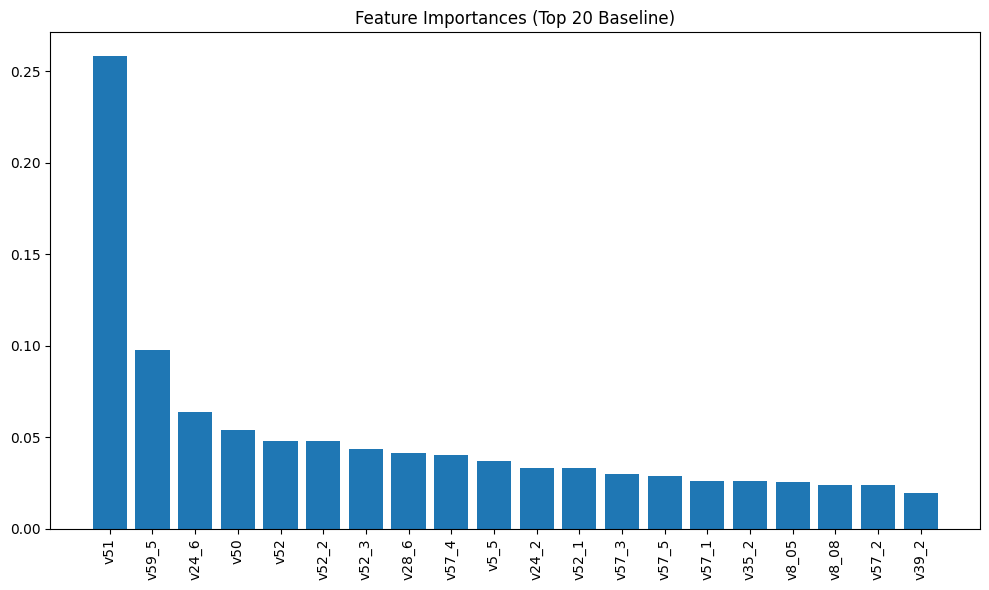

Top 5 Important Features:
v51: 0.2585
v59_5: 0.0977
v24_6: 0.0640
v50: 0.0537
v52: 0.0478


In [6]:
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances (Top 20 Baseline)")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), X_train.columns[indices], rotation=90)
plt.tight_layout()
plt.show()

print("Top 5 Important Features:")
for i in range(5):
    print(f"{X_train.columns[indices[i]]}: {importances[indices[i]]:.4f}")